# Pertemuan 7 — Pengantar Machine Learning: Regresi Linear

**Nama Lengkap** : Muhammad Zacky Kurniawan  
**NIM** : 240401010217  
**Kelas** : IF403

<a href="https://colab.research.google.com/github/zackykurniawan/data-science-2026/blob/main/Pertemuan7_MuhammadZackyKurniawan_240401010217.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Library berhasil diimport ✅')

Library berhasil diimport ✅


---
## Langkah 1 — Generate Dataset & EDA Singkat

In [ ]:
# Generate dataset sintetis prediksi gaji
np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)          # 0–20 tahun
edu        = np.random.choice([0, 1, 2], n)        # SMA=0, D3=1, S1=2
kota       = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu'       : edu,
    'kota'      : kota,
    'gaji'      : gaji
})

print('Shape:', df.shape)
print(df.describe().round(2))

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


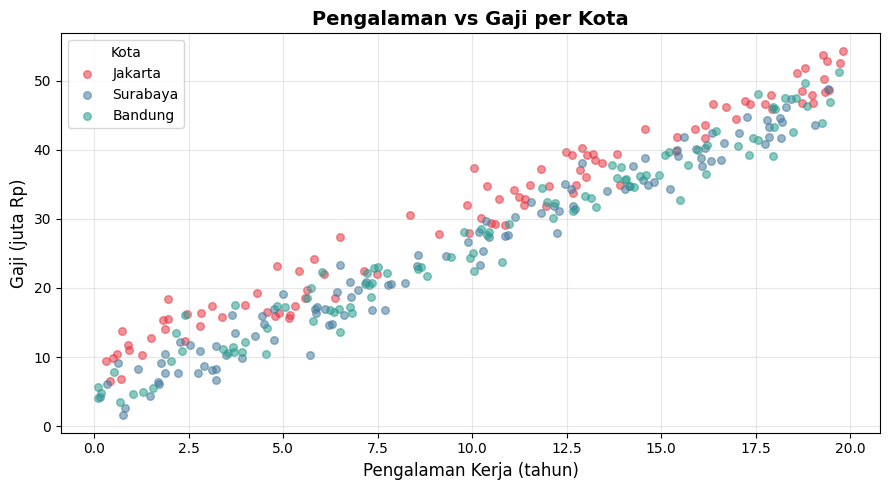

In [ ]:
# Scatter plot: Pengalaman vs Gaji per Kota
fig, ax = plt.subplots(figsize=(9, 5))
palette = {'Jakarta': '#E63946', 'Surabaya': '#457B9D', 'Bandung': '#2A9D8F'}

for k, c in palette.items():
    mask = df['kota'] == k
    ax.scatter(df.loc[mask, 'pengalaman'], df.loc[mask, 'gaji'],
               label=k, alpha=0.55, color=c, s=30)

ax.set_xlabel('Pengalaman Kerja (tahun)', fontsize=12)
ax.set_ylabel('Gaji (juta Rp)', fontsize=12)
ax.set_title('Pengalaman vs Gaji per Kota', fontsize=14, fontweight='bold')
ax.legend(title='Kota')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Langkah 2 — Preprocessing (Encoding, Split, Scaling)

In [ ]:
# One-Hot Encoding kolom 'kota'
df_enc = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)
print('Kolom setelah encoding:', df_enc.columns.tolist())
df_enc.head(3)

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']


In [ ]:
# Pisahkan fitur (X) dan target (y)
X = df_enc.drop('gaji', axis=1)
y = df_enc['gaji']

# Train-Test Split — 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train : {X_train.shape[0]} baris')
print(f'Test  : {X_test.shape[0]} baris')

Train : 240 baris
Test  : 60 baris


In [ ]:
# StandardScaler — fit HANYA pada training set, transform keduanya
scaler     = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)   # fit + transform
X_test_s   = scaler.transform(X_test)        # transform saja (cegah data leakage)

print('Scaling selesai.')
print(f'Mean X_train_s (harusnya ~0): {X_train_s.mean(axis=0).round(3)}')
print(f'Std  X_train_s (harusnya ~1): {X_train_s.std(axis=0).round(3)}')

Scaling selesai.
Mean X_train_s (harusnya ~0): [0.0, 0.0, 0.0, 0.0]
Std  X_train_s (harusnya ~1): [1.0, 1.0, 1.0, 1.0]


---
## Langkah 3 — Latih Model & Tampilkan Koefisien

In [ ]:
# Buat dan latih model Regresi Linear
model = LinearRegression()
model.fit(X_train_s, y_train)

print(f'β₀ (intercept) : {model.intercept_:.3f} juta Rp')
print()

coef_df = pd.DataFrame({
    'Fitur'    : X.columns,
    'Koefisien': model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)

print(coef_df.to_string(index=False))

β₀ (intercept) : 27.514 juta Rp

        Fitur  Koefisien
   pengalaman    13.042
 kota_Jakarta    1.837
          edu    1.188
kota_Surabaya    -0.292


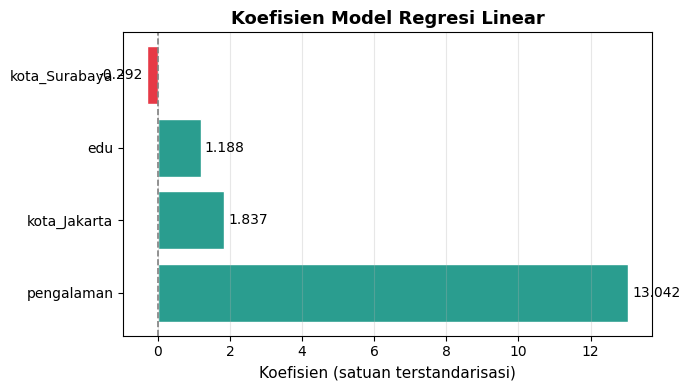

In [ ]:
# Visualisasi koefisien
colors = ['#2A9D8F' if v >= 0 else '#E63946' for v in coef_df['Koefisien']]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors, edgecolor='white')
ax.axvline(0, color='gray', lw=1.2, linestyle='--')
ax.set_xlabel('Koefisien (satuan terstandarisasi)', fontsize=11)
ax.set_title('Koefisien Model Regresi Linear', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Interpretasi Koefisien

- **`pengalaman` (+13.042)** — Fitur paling dominan; setiap 1 standar deviasi kenaikan pengalaman kerja, gaji naik ~13 juta Rp
- **`kota_Jakarta` (+1.837)** — Bekerja di Jakarta memberi tambahan gaji dibanding Bandung (baseline)
- **`edu` (+1.188)** — Pendidikan lebih tinggi berpengaruh positif terhadap gaji
- **`kota_Surabaya` (−0.292)** — Bekerja di Surabaya sedikit lebih rendah dibanding Bandung

> Koefisien dalam satuan terstandarisasi karena input sudah di-*scaling*. Tanda positif = gaji naik, tanda negatif = gaji turun.

---
## Langkah 4 — Evaluasi Model

In [ ]:
# Prediksi pada test set
y_pred = model.predict(X_test_s)

# Hitung metrik evaluasi
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('=' * 40)
print('      METRIK EVALUASI MODEL')
print('=' * 40)
print(f'MAE  = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R²   = {r2:.4f}  ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE - MAE = {rmse - mae:.3f}')
print('=' * 40)

# Verifikasi R² via .score()
r2_check = model.score(X_test_s, y_test)
print(f'Verifikasi R² via .score(): {r2_check:.4f}')

      METRIK EVALUASI MODEL
MAE  = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R²   = 0.9740  (97.4% variasi dijelaskan)
Selisih RMSE - MAE = 0.474
Verifikasi R² via .score(): 0.9740


### Interpretasi Metrik Evaluasi

- **MAE = 1.649 juta Rp** → rata-rata model meleset **±1.649 juta Rp** dari gaji aktual
- **RMSE = 2.123 juta Rp** → sedikit lebih tinggi dari MAE; ada beberapa prediksi yang meleset lebih jauh
- **R² = 0.974** → model berhasil menjelaskan **97.4% variasi** data gaji — performa sangat baik
- **RMSE − MAE = 0.474** → selisih kecil; prediksi cukup seragam, tidak ada outlier prediksi yang ekstrem

---
## Langkah 5 — Visualisasi & Interpretasi

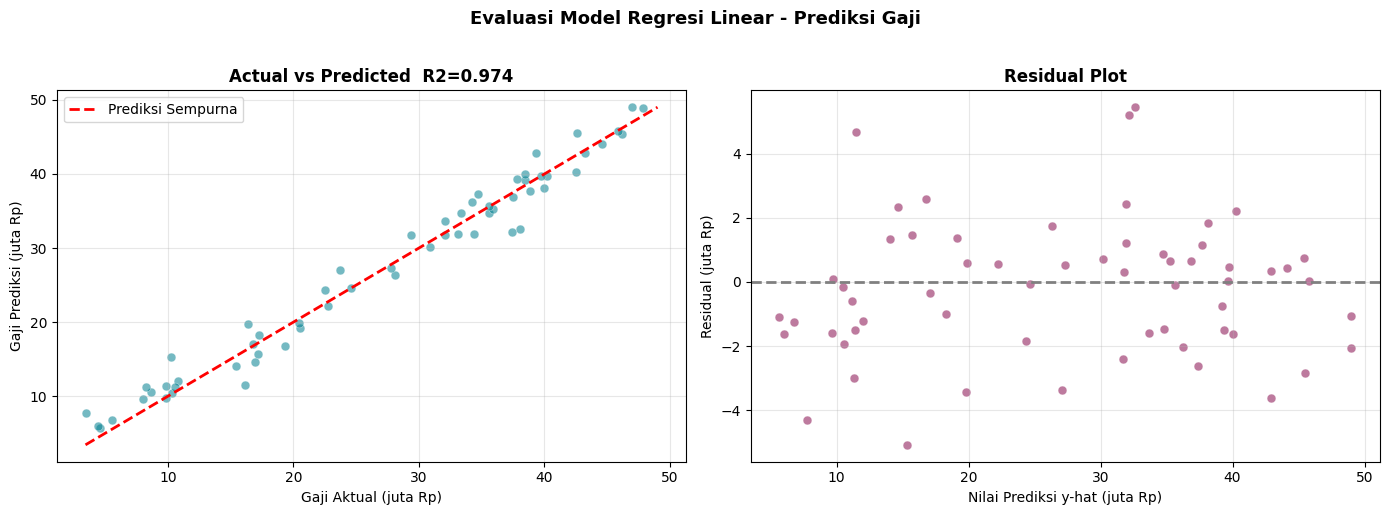

Plot tersimpan: evaluasi_regresi.png ✅


In [ ]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Actual vs Predicted ──────────────────────────────────
axes[0].scatter(y_test, y_pred, alpha=0.55, color='#028090',
                edgecolors='white', lw=0.4, s=40)
lims = [min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)', fontsize=11)
axes[0].set_ylabel('Gaji Prediksi (juta Rp)', fontsize=11)
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.3f})',
                  fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Residual Plot ────────────────────────────────────────
axes[1].scatter(y_pred, residuals, alpha=0.55, color='#880E4F',
                edgecolors='white', lw=0.4, s=40)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)', fontsize=11)
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)', fontsize=11)
axes[1].set_title('Residual Plot', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    'Evaluasi Model Regresi Linear — Prediksi Gaji',
    fontsize=13, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan: evaluasi_regresi.png ✅')

### Interpretasi Visualisasi

**Plot 1 — Actual vs Predicted**
- Titik-titik data tersebar sangat dekat dengan garis merah putus-putus (garis prediksi sempurna)
- Model mampu memprediksi gaji dengan akurasi tinggi di seluruh rentang nilai

**Plot 2 — Residual Plot**
- Residual tersebar secara acak (random) di sekitar garis y=0, tanpa pola yang jelas
- Ini adalah kondisi ideal — asumsi linearitas dan homoscedasticity terpenuhi; model tidak systematically over/under-predict

## Kesimpulan

### Apa yang Dipelajari
Pada pertemuan ketujuh ini, saya mempelajari konsep dasar Machine Learning dan fokus pada algoritma Regresi Linear. Materi mencakup perbedaan Supervised vs Unsupervised Learning, perbedaan tugas Classification dan Regression, serta cara kerja matematis Regresi Linear (persamaan ŷ = β₀ + β₁x, cost function MSE, dan konsep Gradient Descent). Saya juga mengimplementasikan pipeline end-to-end menggunakan `LinearRegression` dari scikit-learn, mulai dari pembuatan dataset sintetis, preprocessing (One-Hot Encoding, train-test split, StandardScaler), pelatihan model, evaluasi dengan tiga metrik (MAE, RMSE, R²), hingga visualisasi Actual vs Predicted dan Residual Plot.

### Temuan Utama
- Model Regresi Linear mencapai **R² = 0.974**, artinya 97.4% variasi gaji berhasil dijelaskan oleh fitur `pengalaman`, `edu`, dan `kota` — performa sangat baik untuk dataset sintetis yang memang dirancang berpola linear.
- Fitur **`pengalaman`** adalah prediktor paling dominan (koefisien +13.042 dalam satuan terstandarisasi), jauh melampaui fitur lain, sesuai dengan formula pembangkit data yang memberikan bobot 2.2 per tahun pengalaman.
- **MAE (1.649) dan RMSE (2.123)** memiliki selisih kecil (0.474), mengindikasikan tidak ada outlier prediksi yang ekstrem dan kesalahan model cukup seragam di seluruh rentang gaji.
- Residual Plot menunjukkan persebaran titik yang acak di sekitar garis y = 0 tanpa pola corong atau kurva, membuktikan asumsi linearitas dan homoscedasticity terpenuhi.
- Urutan pipeline yang benar — encoding → split → scaling — tetap krusial di pertemuan ini; scaling yang dilakukan sebelum split akan menyebabkan data leakage seperti yang telah dipelajari di Pertemuan 6.

### Keterbatasan & Pertanyaan yang Muncul
- Dataset sintetis berpola linear murni, sehingga R² = 0.974 belum tentu bisa direplikasi pada data nyata. Apakah perlu beralih ke Regresi Polinomial atau ensemble jika hubungan X dan y tidak linear?
